# Wind-tunnel Pressure Post-processing - Container Pack

This notebook turns raw wind-tunnel CFD pressure timeseries into the **standard wind-engineering coefficients** for a pack of containers, using AeroSim's `cfdmod` v2 library.

It produces:

- **Cp** - per-triangle pressure coefficient over time.
- **Cf** - horizontal force coefficients (`cf_x`, `cf_y`) per body.
- **Cm** - horizontal moment coefficients (`cm_x`, `cm_y`) per body, evaluated about **each container's footprint mid-point at the base**, i.e. `(mean_x, mean_y, min_z)` of the region's triangle vertices. (You can switch to a multi-corner scan or supply explicit centers of mass via the `CM_LEVER_STRATEGY` knob in the inputs cell, and add `"z"` to `CF_DIRECTIONS` / `CM_DIRECTIONS` in the configs cell if vertical components are needed.)

...together with statistics (mean, RMS, peak min / peak max, mean-equivalent) on each, all rendered as XDMF+H5 ready to open in **ParaView**.

---

## What you need (inputs)

Two XDMF+H5 timeseries from the simulation:

| File | Contents |
|---|---|
| `bodies.body_cp body.h5` | Pressure on every body triangle, per timestep |
| `points.point_cp ref.h5` | Atmospheric reference pressure probe |

Drop them next to this notebook (or change `BODY_H5` / `PROBE_H5` below).

> **Read-only guarantee.** The pipeline never modifies these files; everything is written into `./output/` instead.

## What you get (outputs)

Everything lands **flat** in `./output/` (no nested folders):

| File | Contents |
|---|---|
| `cp.default.time_series.{h5,xdmf}` | Cp animation on the full mesh |
| `Cf.containers.pack.time_series.{h5,xdmf}` | Cf animation with `cf_x` / `cf_y` selectable in ParaView |
| `Cm.containers.pack.time_series.{h5,xdmf}` | Cm animation with `cm_x` / `cm_y` about each container's footprint mid-point |
| `stats.{h5,xdmf}` | Combined statistics for every (coefficient, body, direction) tuple |

> **Self-describing outputs.** Every H5 carries the post-processing parameters that produced it under `/processing_metadata/`. See the *Read embedded metadata* section below.

## Notebook structure

1. **Imports**
2. **Configure inputs** - file paths, time window, physical scaling, statistics, lever strategy
3. **Inspect the geometry** - quick sanity check
4. **Auto-detect container partition** - gap-sweep on triangle centroids
5. **Build the pipeline configurations** - Cp, Cf, Cm
6. **Run Cp** -> **Run Cf** -> **Run Cm**
7. **Verify outputs** - list everything that landed
8. **Read embedded metadata** - recover the exact parameters used
9. **Open in ParaView**
10. **Troubleshooting**

## 1. Imports

Everything we need from `cfdmod` plus `h5py` / `numpy` for the gap-detection cell. The `_PEAK_PARAM_MODELS` map at the bottom is a small lookup so the inputs cell can pick the peak-extreme method by name.

In [ ]:
# Standard library + numerical
import pathlib

import h5py
import numpy as np

# cfdmod v2 -- public API surface (everything we use is importable from `cfdmod` directly)
from cfdmod import (
    BodyConfig,
    BodyDefinition,
    CfCaseConfig,
    CmCaseConfig,
    CpCaseConfig,
    MomentBodyConfig,
    MovingAverageFilter,
    ZoningModel,
    apply_filters,
    mesh_from_h5,
    read_processing_metadata,
    run_cf,
    run_cm,
    run_cp,
)

# Statistic models + the supporting params classes for the peak-method selector
from cfdmod.io.geometry.transformation_config import TransformationConfig
from cfdmod.pressure.parameters import (
    BasicStatisticModel,
    CfConfig,
    CmConfig,
    CpConfig,
    ExtremeAbsoluteParamsModel,
    ExtremeGumbelParamsModel,
    ExtremePeakParamsModel,
    MeanEquivalentParamsModel,
    ParameterizedStatisticModel,
)

# Map "PEAK_METHOD" string -> matching params model class (used in the configs cell).
_PEAK_PARAM_MODELS = {
    "Absolute": ExtremeAbsoluteParamsModel,
    "Peak": ExtremePeakParamsModel,
    "Gumbel": ExtremeGumbelParamsModel,
}

## 2. Configure inputs

The cell below is the **only place a typical run needs editing**. It groups everything by intent:

### File paths
- `BODY_H5`, `PROBE_H5` - solver outputs.
- `OUTPUT` - destination directory; created if missing.

### Reference geometry (optional)
- `REFERENCE_MESH` - when running the same building at several wind directions, each solver run produces a body H5 in its own wind-aligned coordinate frame. Point `REFERENCE_MESH` at a single fixed-frame mesh (`.lnas` / `.stl` / `.h5` / `.xdmf`) to stamp every Cp / Cf / Cm / Ce output with that shared frame instead. Triangle ordering must match the body H5 -- only vertex coordinates may differ. Leave as `None` to keep the body H5's own embedded geometry. Once `run_cp` has used the reference, the downstream `run_cf` / `run_cm` calls inherit it through `cp_h5` automatically -- no `mesh_path=` repeats required.

### Geometry / region partition
- `GAP_M` - minimum xy/z gap (in metres) used to detect container boundaries from triangle centroids. The default `1.0 m` works for typical container packs.
- `BODY_NAME` - label used to identify the body inside the output H5/XDMF. Cosmetic.

### Time window
- `T_MIN`, `T_MAX` - crop the simulation timeseries before computing Cp. Either bound can be `None` to fall back to the body H5's full range; both are clamped against the data so a misconfigured value can't widen beyond what's in the file.

### Flow / scaling (must match the simulation set-up)
- `SIMUL_U_H` - reference flow velocity at the building height (used in dynamic pressure; also used as the time scale `L/U` when `NORMALIZE_TIME=True`).
- `SIMUL_CHARACTERISTIC_LENGTH` - characteristic length used as the time scale `L/U` when `NORMALIZE_TIME=True`. Otherwise unused.
- `FLUID_DENSITY` - fluid density (typically `1.225 kg/m^3` for air at sea level).
- `MACROSCOPIC_TYPE` - `"pressure"` if the solver wrote real pressure (the default), or `"rho"` if it wrote LBM density.
- `REFERENCE_PRESSURE` - how the reference pressure is taken from the probe H5. `"probe"` (the default) uses the first probe point -- the reference probe placed above the body, the standard wind-tunnel choice. `"average"` takes the spatial mean across all probe points at each timestep.
- `NORMALIZE_TIME` - when `True`, the time axis written to `/meta/time_normalized` in the Cp output is divided by `L/U` (convective-time normalisation); the same axis is used by every downstream coefficient and by the stats / filter windows. When `False` (the default), the time axis is the raw solver time -- nothing is silently rescaled. This is on purpose: the only place `cfdmod` ever scales time is here, opt-in.

### Cf / Cm reference area + volume (required)
- `NOMINAL_AREA`, `NOMINAL_VOLUME` - reference area / volume used to non-dimensionalise Cf / Cm. **Required**: cfdmod will not pick a tribute area or volume for you, since without an explicit reference value the resulting coefficients cannot be converted back to real-scale Forces / Moments unambiguously. Use the real-scale figures (e.g. building frontal area, bounding-box volume) you want the coefficients normalised against.

### Filters (optional)
- `CP_FILTERS` - a list of filter specs applied in order to the Cp timeseries to produce a new `*.time_series.h5`. The filtered Cp file then feeds Cf / Cm in place of the raw Cp -- so any smoothing decision is explicit, traceable (the filter chain is recorded in the output's `/processing_metadata`), and reusable. Leave the list empty to skip the filter step. Available filter kinds today: `MovingAverageFilter(window=...)`. Window units match the input file's time axis (raw solver time when `NORMALIZE_TIME=False`).

### Statistics
- `PEAK_METHOD` + `PEAK_PARAMS` - pick the peak-factor estimator for the `min` / `max` columns of every coefficient's stats. Three options: `"Absolute"` (raw signal min/max, no model), `"Peak"` (gust factor: `mean +/- peak_factor * rms`), or `"Gumbel"` (extreme-value fit on subdivision maxima/minima). For Gumbel, `full_scale_U_H` and `full_scale_characteristic_length` are required for Cp; for Cf / Cm they are inherited from the Cp metadata embedded in `cp_h5` if omitted. Moving-average smoothing is *not* a peak method -- if you want stats over a smoothed series, run `apply_filters` first (via the `CP_FILTERS` knob) and then run stats on the filtered file.

### Moment-center strategy
- `CM_LEVER_STRATEGY` - how each container's overturning moment center is chosen. Default `"region_base"` puts the center at the **footprint mid-point at the base** `(mean_x, mean_y, min_z)`. Alternatives:
  - `"region_bbox_corners_xy"` - runs Cm four times per container, once with the moment center at each xy bbox corner at z=min. Useful for bracketing the worst-case overturning moment per direction.
  - `"fixed"` - uses a single user-supplied `lever_origin` for every triangle.
  - For an arbitrary set of explicit centers (e.g. HFPI-style externally-known centers of mass), set `region_lever_origins={region_int: (x, y, z), ...}` or `lever_origin_cases={"label": {region_int: (x, y, z), ...}, ...}` directly on the `MomentBodyConfig` in the configs cell.

In [ ]:
# --- File paths ----------------------------------------------------------
REPO_ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
BODY_H5 = REPO_ROOT / "bodies.body_cp body.h5"
PROBE_H5 = REPO_ROOT / "points.point_cp ref.h5"
OUTPUT = REPO_ROOT / "output"

# --- Reference geometry (optional) ---------------------------------------
# When the same building is simulated for several wind directions, each run
# produces a body H5 in its own (wind-aligned, "spun") coordinate frame.
# Set REFERENCE_MESH to a single fixed-frame mesh (.lnas / .stl / .h5 /
# .xdmf) and the Cp output (and everything downstream from it: Cf, Cm,
# Ce) is written in that shared frame. Triangle ordering must match the
# body H5 -- only vertex coordinates may differ. Leave as None to keep the
# body H5's own embedded geometry.
REFERENCE_MESH: pathlib.Path | None = None
# REFERENCE_MESH = REPO_ROOT / "reference.stl"

# --- Geometry / region partition -----------------------------------------
GAP_M = 1.0          # min xy/z gap (m) between containers in the geometry
BODY_NAME = "pack"   # label for the (whole) body in Cf / Cm configs

# --- Time window ---------------------------------------------------------
# Either bound can be None to fall back to the body H5's own range.
T_MIN: float | None = 150.0
T_MAX: float | None = None

# --- Flow / scaling ------------------------------------------------------
# Must match the simulation set-up (see the markdown above for descriptions).
SIMUL_U_H = 15.0
SIMUL_CHARACTERISTIC_LENGTH = 22.0
FLUID_DENSITY = 1.225
MACROSCOPIC_TYPE = "pressure"            # 'pressure' (default) or 'rho'
REFERENCE_PRESSURE = "probe"             # 'probe' (point above body, default) or 'average' (spatial mean across probe points)
NORMALIZE_TIME = False                   # False (default) -> raw solver time on disk; True -> divide by L/U (convective time)

# --- Cf / Cm reference area + volume -------------------------------------
# Required: cfdmod will not pick a tribute area/volume for you. Use the
# real-scale reference values you want Cf/Cm normalised against so the
# coefficients can be converted back to Forces / Moments unambiguously.
NOMINAL_AREA = 1.0      # m^2 -- e.g. building frontal area
NOMINAL_VOLUME = 1.0    # m^3 -- e.g. building bounding-box volume

# --- Filters (optional) -------------------------------------------------
# Filters are an opt-in pipeline step: take any *.time_series.h5, apply a
# chain in order, and write a new *.time_series.h5. Available filter
# kinds today: MovingAverageFilter(window=...). Window is in the same
# units as the input file's time axis (raw solver time when
# NORMALIZE_TIME=False; convective time when True). Leave the list empty
# to skip the filter step entirely.
CP_FILTERS: list = []
# CP_FILTERS = [MovingAverageFilter(window=2.0)]   # e.g. 2-second smoothing

# --- Statistics: peak-extreme method ------------------------------------
# Pick one and (optionally) tweak its params dict. The non-selected entry
# is ignored.
PEAK_METHOD = "Peak"
PEAK_PARAMS: dict = {
    "Absolute": {},
    "Peak": {"peak_factor": 3.0},
    "Gumbel": {
        "peak_duration": 3.0,
        "event_duration": 600.0,
        "n_subdivisions": 10,
        "non_exceedance_probability": 0.78,
        # full_scale_U_H / full_scale_characteristic_length are required
        # for Cp; for Cf/Cm they are inherited from the Cp metadata if
        # omitted (so you only need to specify them in the Cp scope).
        "full_scale_U_H": 30.0,
        "full_scale_characteristic_length": SIMUL_CHARACTERISTIC_LENGTH,
    },
}[PEAK_METHOD]

# --- Cm moment-center strategy ------------------------------------------
# 'region_base'             -> one center per container at (mean_x, mean_y, min_z)
# 'region_bbox_corners_xy'  -> 4 independent runs per container (xmin/max x ymin/max at z=min)
# 'fixed'                   -> use a single lever_origin (set in the configs cell)
CM_LEVER_STRATEGY = "region_base"

# --- Sanity check + create the output directory ------------------------
OUTPUT.mkdir(parents=True, exist_ok=True)
assert BODY_H5.exists(), f"Body H5 not found at {BODY_H5}"
assert PROBE_H5.exists(), f"Probe H5 not found at {PROBE_H5}"
if REFERENCE_MESH is not None:
    assert REFERENCE_MESH.exists(), f"Reference mesh not found at {REFERENCE_MESH}"

print("Inputs:")
print(f"  body : {BODY_H5}")
print(f"  probe: {PROBE_H5}")
print(f"  reference mesh: {REFERENCE_MESH if REFERENCE_MESH is not None else '<from body H5>'}")
print(f"Output: {OUTPUT}")
print(f"Time axis: {'normalized (raw / L/U)' if NORMALIZE_TIME else 'raw solver time'}")
print(f"Lever strategy for Cm: {CM_LEVER_STRATEGY!r}")
print(f"Peak-extreme method:    {PEAK_METHOD!r}  with params {PEAK_PARAMS}")
print(f"Cp filters: {CP_FILTERS or '<none>'}")

## 3. Inspect the geometry

Quick sanity check: load the mesh that lives inside the body H5. The bounds and triangle count below should match what you expect from the simulation case.

> If you have a stand-alone mesh (`.stl` / `.h5` / `.xdmf`), pass it via `mesh_path=` to any `run_*` call and that takes precedence over the body's embedded geometry.

In [3]:
mesh = mesh_from_h5(BODY_H5)
verts = mesh.geometry.vertices

print(f"Triangles: {len(mesh.geometry.triangles):,}")
print(f"Vertices : {len(verts):,}")
print(
    f"Bounding box: "
    f"x=[{verts[:,0].min():.2f}, {verts[:,0].max():.2f}], "
    f"y=[{verts[:,1].min():.2f}, {verts[:,1].max():.2f}], "
    f"z=[{verts[:,2].min():.2f}, {verts[:,2].max():.2f}]"
)

Triangles: 83,715
Vertices : 43,015
Bounding box: x=[-92.48, 106.52], y=[-133.05, 149.95], z=[19.05, 42.47]


## 4. Auto-detect the container partition

Each individual container becomes a **region** that Cf and Cm aggregate over. Instead of asking the user to author surfaces or hand-list intervals, the algorithm detects regions directly from the geometry:

1. Project triangle centroids onto each axis.
2. Sort the projected coordinates and find consecutive jumps wider than `GAP_M`.
3. Place an interval boundary at the **midpoint of every such gap**.

The resulting `ZoningModel` is dropped straight into the body config below, so each Cartesian cell of the resulting partition becomes one region in the Cf/Cm output.

The print at the bottom tells you how many bins (`= containers`) were detected on each axis.

In [4]:
def detect_intervals(coords: np.ndarray, gap: float = GAP_M) -> list[float]:
    """Sort 1-D coordinates and return [-inf, midpoint of every >gap jump, +inf]."""
    s = np.sort(coords)
    diffs = np.diff(s)
    splits = np.where(diffs > gap)[0]
    boundaries = [float((s[i] + s[i + 1]) / 2) for i in splits]
    return [float("-inf"), *boundaries, float("inf")]


centroids = np.mean(mesh.geometry.triangle_vertices, axis=1)
zoning = ZoningModel(
    x_intervals=detect_intervals(centroids[:, 0]),
    y_intervals=detect_intervals(centroids[:, 1]),
    z_intervals=detect_intervals(centroids[:, 2]),
)
n_x = max(1, len(zoning.x_intervals) - 1)
n_y = max(1, len(zoning.y_intervals) - 1)
n_z = max(1, len(zoning.z_intervals) - 1)

print(f"Container partition (gap > {GAP_M} m):")
print(f"  x: {len(zoning.x_intervals) - 2} interior boundary(ies) -> {n_x} bin(s)")
print(f"  y: {len(zoning.y_intervals) - 2} interior boundary(ies) -> {n_y} bin(s)")
print(f"  z: {len(zoning.z_intervals) - 2} interior boundary(ies) -> {n_z} bin(s)")
print(f"  total cells (some may be empty): {n_x * n_y * n_z}")

Container partition (gap > 1.0 m):
  x: 3 interior boundary(ies) -> 4 bin(s)
  y: 1 interior boundary(ies) -> 2 bin(s)
  z: 0 interior boundary(ies) -> 1 bin(s)
  total cells (some may be empty): 8


## 5. Build the pipeline configurations

Three configs are built from the constants defined above:

| Config | Goes into |
|---|---|
| `cp_cfg` | `run_cp` - Cp transform parameters + statistics + time window |
| `cf_cfg` | `run_cf` - Cf body definition (whole pack), zoning into containers, directions, statistics |
| `cm_cfg` | `run_cm` - same as Cf but with the moment-center strategy attached to the body |

`BodyDefinition(surfaces=[])` means *use every surface in the mesh* - handy when the body H5 is a single unsegmented mesh (the most common case from the solver). If you have an LNAS with named surfaces, list them by name here instead.

The cell also derives the **time window** by intersecting your `T_MIN`/`T_MAX` with the body H5's actual extent (so accidental over-wide bounds don't cause issues). The chosen window is printed for confirmation.

> All three configs are passed *directly* to the run functions below; no sidecar YAML files are written. The full config is also embedded inside every output H5 under `/processing_metadata/`, so the canonical record lives alongside the data it produced.

In [ ]:
# --- Resolve the time window against the body H5's actual extent ---------
def detect_time_range(body_h5: pathlib.Path) -> tuple[float, float]:
    with h5py.File(body_h5, "r") as f:
        keys = list(f["pressure"].keys())
    times = sorted(float(k[1:]) for k in keys)
    return float(times[0]), float(times[-1])


detected_range = detect_time_range(BODY_H5)
timestep_range = (
    detected_range[0] if T_MIN is None else max(float(T_MIN), detected_range[0]),
    detected_range[1] if T_MAX is None else min(float(T_MAX), detected_range[1]),
)
print(f"Body H5 time range:    [{detected_range[0]:.3f}, {detected_range[1]:.3f}]")
print(f"Cropped to:            [{timestep_range[0]:.3f}, {timestep_range[1]:.3f}]")
assert timestep_range[0] < timestep_range[1], "empty time window"

# --- Build the statistics list, with the chosen peak-extreme params ------
peak_params = _PEAK_PARAM_MODELS[PEAK_METHOD](**PEAK_PARAMS)
STATISTICS = [
    BasicStatisticModel(stats="mean"),
    BasicStatisticModel(stats="rms"),
    ParameterizedStatisticModel(stats="mean_eq", params=MeanEquivalentParamsModel(scale_factor=0.61)),
    ParameterizedStatisticModel(stats="min", params=peak_params),
    ParameterizedStatisticModel(stats="max", params=peak_params),
]

# Direction lists: this case only needs the horizontal (x, y) components for
# both the resultant force and the overturning moments. Add "z" if vertical
# components are also of interest.
CF_DIRECTIONS = ["x", "y"]
CM_DIRECTIONS = ["x", "y"]

# --- Cp config ----------------------------------------------------------
cp_cfg = CpCaseConfig(
    pressure_coefficient={
        "default": CpConfig(
            statistics=STATISTICS,
            timestep_range=timestep_range,
            simul_U_H=SIMUL_U_H,
            simul_characteristic_length=SIMUL_CHARACTERISTIC_LENGTH,
            fluid_density=FLUID_DENSITY,
            macroscopic_type=MACROSCOPIC_TYPE,
            reference_pressure=REFERENCE_PRESSURE,
            normalize_time=NORMALIZE_TIME,
        )
    }
)

# --- Cf config ----------------------------------------------------------
# BodyDefinition(surfaces=[]) -> "every surface in the mesh" (i.e. the whole
# pack, which is what the unsegmented body H5 contains).
cf_cfg = CfCaseConfig(
    bodies={BODY_NAME: BodyDefinition(surfaces=[])},
    force_coefficient={
        "containers": CfConfig(
            statistics=STATISTICS,
            bodies=[BodyConfig(name=BODY_NAME, sub_bodies=zoning)],
            directions=CF_DIRECTIONS,
            nominal_area=NOMINAL_AREA,
            transformation=TransformationConfig(),
        )
    },
)

# --- Cm config ----------------------------------------------------------
# The lever strategy is the only Cm-specific knob beyond what Cf needs.
cm_cfg = CmCaseConfig(
    bodies={BODY_NAME: BodyDefinition(surfaces=[])},
    moment_coefficient={
        "containers": CmConfig(
            statistics=STATISTICS,
            bodies=[
                MomentBodyConfig(
                    name=BODY_NAME,
                    sub_bodies=zoning,
                    lever_strategy=CM_LEVER_STRATEGY,
                )
            ],
            directions=CM_DIRECTIONS,
            nominal_volume=NOMINAL_VOLUME,
            transformation=TransformationConfig(),
        )
    },
)

print("\nConfigs built.")
print(f"  Cp: 1 label ('default'), {len(STATISTICS)} stats")
print(f"  Cf: 1 body ({BODY_NAME!r}) split into {n_x * n_y * n_z} region(s); directions={CF_DIRECTIONS}; nominal_area={NOMINAL_AREA}")
print(f"  Cm: 1 body ({BODY_NAME!r}) with lever_strategy={CM_LEVER_STRATEGY!r}; directions={CM_DIRECTIONS}; nominal_volume={NOMINAL_VOLUME}")

## 6a. Run Cp

Reads the body H5 + probe H5 in chunks, applies the Cp transform per timestep, and **streams the result to disk** as `output/cp.default.time_series.{h5,xdmf}` (one timestep per `/cp/t{T}` dataset, plus `/Triangles + /Geometry` so ParaView can render it directly).

After the timeseries is on disk, statistics are computed in a single pass and appended to `output/stats.h5` under `/cp/default/`. The body and probe H5 files are never modified.

In [ ]:
run_cp(
    body_h5=BODY_H5,
    probe_h5=PROBE_H5,
    cfg_path=cp_cfg,    # in-memory CaseConfig; YAML path also accepted
    output=OUTPUT,
    mesh_path=REFERENCE_MESH,   # None -> embedded body H5 geometry; set above to use a fixed reference frame
)
CP_TIMESERIES = OUTPUT / "cp.default.time_series.h5"
print(f"Cp timeseries written to {CP_TIMESERIES.relative_to(REPO_ROOT)}")

# Optional filter step: stream cp.h5 -> cp.filtered.h5 with the chain
# specified in CP_FILTERS. Cf / Cm below then read CP_TIMESERIES, which
# points at whichever file is current. The filter chain is recorded in
# the filtered file's /processing_metadata.
if CP_FILTERS:
    CP_FILTERED = OUTPUT / "cp.default.filtered.time_series.h5"
    apply_filters(CP_TIMESERIES, CP_FILTERED, filters=CP_FILTERS, group="cp")
    CP_TIMESERIES = CP_FILTERED
    print(f"Cp filtered to     {CP_TIMESERIES.relative_to(REPO_ROOT)} (chain: {CP_FILTERS})")

print(
    "  (Cp output embeds "
    f"{'REFERENCE_MESH' if REFERENCE_MESH is not None else 'body H5 geometry'};"
    " run_cf / run_cm below inherit it from the cp_h5 -- no mesh_path needed.)"
)

## 6b. Run Cf

Streams Cp from the timeseries on disk, applies the Cf transform per region (per container), broadcasts the per-region values onto each body triangle, and writes one `output/Cf.containers.pack.time_series.{h5,xdmf}` with two groups (`cf_x`, `cf_y`) -- in ParaView you pick the direction from the **Attribute selector** on the same animation.

Statistics land in `stats.h5` under `/cf_{x,y}/containers/pack/`. To also compute the vertical force component, add `"z"` to `CF_DIRECTIONS` in the configs cell above.

In [7]:
run_cf(
    cp_h5=CP_TIMESERIES,
    cfg_path=cf_cfg,
    output=OUTPUT,
)

[2026-04-29 23:58:36,074] [INFO] - cfdmod - Processing Cf: containers


[2026-04-29 23:58:54,437] [INFO] - cfdmod - Cf stats written for config 'containers'


## 6c. Run Cm

Same disk-first contract as Cf, but with **per-region moment centers** chosen by `CM_LEVER_STRATEGY`.

For the default `"region_base"`: each container's moment center is its own footprint mid-point at the base, i.e. `(mean_x, mean_y, min_z)` of the region's triangle vertices. Output is one `Cm.containers.pack.time_series.{h5,xdmf}` with `cm_x` / `cm_y` groups, and stats under `/cm_{x,y}/containers/pack/` in `stats.h5`. Add `"z"` to `CM_DIRECTIONS` in the configs cell if you also want the vertical (twisting) moment.

If you switch `CM_LEVER_STRATEGY` to `"region_bbox_corners_xy"`, the body is expanded into **four independent runs** -- one per xy-corner of each container's footprint at z=min -- so you get `Cm.containers.pack.{xmin_ymin,xmin_ymax,xmax_ymin,xmax_ymax}.time_series.{h5,xdmf}` and matching `cm_{x,y}/containers/pack.{case}` stats subgroups, ready for a worst-case comparison.

In [8]:
run_cm(
    cp_h5=CP_TIMESERIES,
    cfg_path=cm_cfg,
    output=OUTPUT,
)

[2026-04-29 23:58:54,442] [INFO] - cfdmod - Processing Cm: containers


[2026-04-29 23:59:14,753] [INFO] - cfdmod - Cm stats written for config 'containers'


## 7. Verify outputs

Walks `output/stats.h5` and lists every leaf group with an embedded mesh + the stat datasets it contains. Each row corresponds to **one `<Grid>`** in `stats.xdmf`, on the matching mesh -- so `n_tri` is what ParaView will render that group on. There should be no length mismatches.

In [9]:
def list_stats_leaves(stats_h5: pathlib.Path) -> list[tuple[str, int, list[str]]]:
    """Walk a stats H5 and return (group_path, n_tri, [stat_names]) per leaf
    group with embedded mesh."""
    rows: list[tuple[str, int, list[str]]] = []
    with h5py.File(stats_h5, "r") as f:
        def visit(name, obj):
            if isinstance(obj, h5py.Group) and "Triangles" in obj and "Geometry" in obj:
                n_tri = obj["Triangles"].shape[0]
                stats = sorted(
                    k for k in obj
                    if k not in ("Triangles", "Geometry", "processing_metadata")
                    and isinstance(obj[k], h5py.Dataset)
                )
                rows.append((name, n_tri, stats))
        f.visititems(visit)
    return rows


print("All output files:\n")
for p in sorted(OUTPUT.iterdir()):
    if p.is_file():
        print(f"  {p.name}")

print("\nstats.h5 contents:\n")
print(f"  {'group':50s}  n_tri    stats")
print(f"  {'-' * 50}  ------   {'-' * 32}")
for name, n_tri, stats in list_stats_leaves(OUTPUT / "stats.h5"):
    print(f"  /{name:48s}  {n_tri:>6d}   {', '.join(stats)}")

All output files:

  Cf.containers.pack.time_series.h5
  Cf.containers.pack.time_series.xdmf
  Cm.containers.pack.time_series.h5
  Cm.containers.pack.time_series.xdmf
  cp.default.time_series.h5
  cp.default.time_series.xdmf
  stats.h5
  stats.xdmf

stats.h5 contents:

  group                                               n_tri    stats
  --------------------------------------------------  ------   --------------------------------
  /cf_x/containers/pack                               83715   max, mean, mean_eq, min, rms
  /cf_y/containers/pack                               83715   max, mean, mean_eq, min, rms
  /cm_x/containers/pack                               83715   max, mean, mean_eq, min, rms
  /cm_y/containers/pack                               83715   max, mean, mean_eq, min, rms
  /cp/default                                         83715   max, mean, mean_eq, min, rms


## 8. Read embedded post-processing metadata

Every output H5 carries the parameters that produced it under `/processing_metadata/`. This is the canonical record (no separate sidecar YAML to lose).

For a timeseries file the metadata sits at the root group; for `stats.h5` it sits at every leaf group, so you can recover what was used to compute that specific stat block.

In [10]:
md_cp_ts = read_processing_metadata(OUTPUT / "cp.default.time_series.h5", "/")
print("Cp timeseries metadata")
print(f"  produced_at:    {md_cp_ts['produced_at']}")
print(f"  cfdmod_version: {md_cp_ts['cfdmod_version']}")
print(f"  body_h5:        {md_cp_ts['body_h5']}")
print(f"  probe_h5:       {md_cp_ts['probe_h5']}")
print(f"  cp config keys: {sorted(md_cp_ts['config'].keys())}")

md_cm_stats = read_processing_metadata(OUTPUT / "stats.h5", f"cm_x/containers/{BODY_NAME}")
print("\nCm-x stats group metadata")
print(f"  body / direction: {md_cm_stats.get('body')} / {md_cm_stats.get('direction')}")
print(f"  cm config keys:   {sorted(md_cm_stats['config'].keys())}")

Cp timeseries metadata
  produced_at:    2026-04-30T02:58:31.063496+00:00
  cfdmod_version: 2.0.0
  body_h5:        /home/waine/Documents/Codigos/AeroSim/cfdmod/bodies.body_cp body.h5
  probe_h5:       /home/waine/Documents/Codigos/AeroSim/cfdmod/points.point_cp ref.h5
  cp config keys: ['fluid_density', 'macroscopic_type', 'simul_U_H', 'simul_characteristic_length', 'statistics', 'timestep_range']

Cm-x stats group metadata
  body / direction: pack / x
  cm config keys:   ['bodies', 'directions', 'nominal_volume', 'statistics', 'transformation']


## 8b. Pull a timeseries into pandas, save as CSV, plot

`cfdmod.io.read_timeseries_df` flattens any timeseries H5 into a wide-form `pandas.DataFrame` (rows = `time_normalized`, columns = triangle index or region representative), suitable for direct CSV export, spreadsheet ingest, or quick `matplotlib` plots.

For Cf and Cm the values are constant within a region, so the most useful view is `regions=True`: one column per container.

Cf_x DataFrame: (704, 8)
  index: time_normalized, range [0.00, 703.00]
  columns (representative triangle indices): [0, 2440, 5283, 19291, 22085, 27673, 63404, 70200]

First rows:
                      0          2440        5283       19291      22085  \
time_normalized                                                            
0.0              126.371867 -10.023467  112.343815 -21.249803 -22.433800   
1.0              126.624205  -9.382279  112.421075 -21.893288 -22.799907   
2.0              127.145227  -9.024305  112.822527 -22.355715 -22.963654   
3.0              127.260863  -9.283300  113.087577 -22.625025 -23.039773   
4.0              127.699158  -9.166862  113.373851 -23.144676 -22.909413   

                     27673     63404      70200  
time_normalized                                  
0.0             -18.907641  4.560012 -14.569483  
1.0             -18.284854  4.748705 -15.069582  
2.0             -17.730392  4.682150 -14.540808  
3.0             -16.991786  4.752658

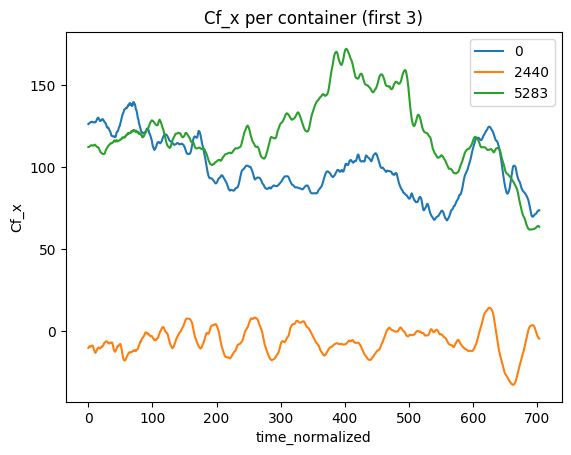

In [11]:
from cfdmod import plot_timeseries, read_timeseries_df, to_csv

CF_TIMESERIES = OUTPUT / "Cf.containers.pack.time_series.h5"
CM_TIMESERIES = OUTPUT / "Cm.containers.pack.time_series.h5"

# One column per container (constant per region -> deduplicated by value).
cf_x_df = read_timeseries_df(CF_TIMESERIES, "cf_x", regions=True)
cm_y_df = read_timeseries_df(CM_TIMESERIES, "cm_y", regions=True)

print(f"Cf_x DataFrame: {cf_x_df.shape}")
print(f"  index: {cf_x_df.index.name}, range [{cf_x_df.index.min():.2f}, {cf_x_df.index.max():.2f}]")
print(f"  columns (representative triangle indices): {list(cf_x_df.columns)}")
print(f"\nFirst rows:")
print(cf_x_df.head())

# Drop straight to CSV for spreadsheets.
to_csv(cf_x_df, OUTPUT / "Cf_x.regions.csv")
to_csv(cm_y_df, OUTPUT / "Cm_y.regions.csv")
print(f"\nWrote {OUTPUT / 'Cf_x.regions.csv'}")
print(f"Wrote {OUTPUT / 'Cm_y.regions.csv'}")

# Quick plot of the first three containers.
ax = plot_timeseries(
    cf_x_df,
    columns=list(cf_x_df.columns)[:3],
    title="Cf_x per container (first 3)",
    ylabel="Cf_x",
)

## 9. Open in ParaView

Everything is flat under `./output/`. Open the `.xdmf` file you want; ParaView reads the data from the sibling `.h5` automatically.

| File | What ParaView shows |
|---|---|
| `output/stats.xdmf` | One `<Grid>` per `(coefficient, direction[, case], body)` -- click the eye icon next to each to compare. Pick the stat (`mean`, `rms`, `min`, `max`, `mean_eq`) from the **Coloring** dropdown. |
| `output/cp.default.time_series.xdmf` | Cp animation on the full mesh. Use the timestep slider; `cp` is the only Attribute. |
| `output/Cf.containers.pack.time_series.xdmf` | Cf animation. Same animation timeline; pick `cf_x` / `cf_y` from the **Coloring** dropdown to switch direction. |
| `output/Cm.containers.pack.time_series.xdmf` | Cm animation. Same as Cf for `cm_x` / `cm_y`. With `lever_strategy='region_bbox_corners_xy'` you'll instead see four files (`Cm.containers.pack.{xmin_ymin,...}.time_series.xdmf`) -- open them as separate layers to compare corners. |

Tip: in ParaView's *Properties* panel, set **Representation -> Surface With Edges** to see the triangle mesh underlying the colour map.

---

## 10. Troubleshooting

**The pipeline says my body H5 is missing.**
Check that `BODY_H5` in the inputs cell points at the actual file. The path is resolved relative to the repo root (one level up from `notebooks/` if you run the notebook from there).

**`Empty time window` assertion.**
`T_MIN` and `T_MAX` are clamped to the body H5's range, but if you set `T_MIN >= max(t)` the window collapses. Lower `T_MIN` (or set it to `None`) and re-run.

**Container partition has too many bins.**
The `>GAP_M` rule treats *any* gap between two consecutive triangle centroids as a region boundary. If your mesh has fine internal voids that aren't real container separations, raise `GAP_M`.

**Container partition has too few bins (1 region).**
Triangle centroids on the affected axis don't have any gap > `GAP_M`. Lower `GAP_M` -- or, if the geometry really doesn't separate the containers, you'll need to author the intervals manually:
```python
zoning = ZoningModel(x_intervals=[-inf, x1, x2, inf], y_intervals=[...], z_intervals=[...])
```

**ParaView shows NaN / blank cells in Ce.**
Expected when the zoning subdivides finer than the data. The pipeline emits a warning at run time. Coarsen the zoning or confirm the source data has enough resolution.

**Need explicit centers of mass for Cm (HFPI use case).**
Replace `lever_strategy=CM_LEVER_STRATEGY` with `region_lever_origins={0: (x0, y0, z0), 1: (x1, y1, z1), ...}` on the `MomentBodyConfig`. Region indices follow the order of the auto-detected zoning -- inspect `zoning` in the partition cell to map them to physical containers.

**Want to scan multiple candidate centers per container.**
Use `lever_origin_cases={"label_a": {0: (...), ...}, "label_b": {0: (...), ...}}`. Each case becomes its own `Cm.containers.pack.{label}.time_series.{h5,xdmf}` and stats subgroup.

**Want vertical force / moment components too.**
Add `"z"` to `CF_DIRECTIONS` and/or `CM_DIRECTIONS` in the configs cell and re-run the matching `run_cf` / `run_cm`. New `cf_z` / `cm_z` groups will appear in the timeseries and `stats.h5` automatically.

**Want to drive the pipeline from the command line instead of this notebook.**
Every `run_*` call here also has a CLI counterpart:
```bash
python -m cfdmod pressure cp --body BODY.h5 --probe PROBE.h5 --config cp.yaml --output output
python -m cfdmod pressure cf --cp output/cp.default.time_series.h5 --config cf.yaml --output output
python -m cfdmod pressure cm --cp output/cp.default.time_series.h5 --config cm.yaml --output output
```
`--mesh` is optional everywhere; pass an `.lnas` / `.stl` / `.h5` / `.xdmf` to override the geometry source.